# LLM Agora Persona Demo
Interactively run a persona-driven Agora session that mirrors the CLI experience.

## Instructions
- Ensure `.env` defines `OPENROUTER_API_KEY`.
- Adjust persona/question IDs and models to explore different matchups.
- The same helpers power the CLI (`agora persona ...`).

This walkthrough uses the bundled prompt catalog at `../data/prompts.json` (selecting the `default` set).

In [1]:
import sys
sys.path.append("../src")

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
from dotenv import load_dotenv
load_dotenv()

from agora.plotting import collect_agent_metrics, plot_metrics
from agora.workflows import (
    build_persona_agent_configs,
    load_persona_catalog,
    load_question_catalog,
    load_prompt_catalog,
    print_agent_histories,
    run_debate_session,
)

# Persona debate configuration
Configure participant personas, question, and runtime controls.

In [3]:
# Load the available configurations
prompt_path = Path('../data/prompts.json')
personas_path = Path('../data/personas.json')
questions_path = Path('../data/questions.json')

personas = load_persona_catalog(personas_path)
questions = load_question_catalog(questions_path)
prompt_catalog = load_prompt_catalog(prompt_path)

In [4]:
# Base prompt, instructions, etc.
prompt_set = 'default'
# The topic of the interaction
question_id = 'work'

# Agent personas
alpha_persona_id = 'high_wealth_founder'
beta_persona_id = 'unionized_warehouse_worker'

# Agent models
alpha_model = 'openai/gpt-4o-mini'
beta_model = 'anthropic/claude-sonnet-4.5'

# Interaction length
turns_per_agent = 20

# I/O
snapshot_path = Path('../snapshots/reflection_snapshot.json')
load_snapshot_flag = False
save_snapshot_flag = True

# Interaction controls
private_response_keep = False
pre_interview_keep = False
post_interview_keep = False
skip_first_agent_first_reflection = True

In [5]:
# personas[alpha_persona_id]
# alpha_persona_id
personas['personas'][beta_persona_id]

{'id': 'unionized_warehouse_worker',
 'name': 'Unionized Warehouse Worker',
 'actual_persona': 'Role & context: Full-time logistics employee under a collective bargaining agreement. Scale: Scheduled ~36–44 hours/week; overtime paid at a higher contractual rate. Authorities/resources: May file safety reports; use a grievance process; vote on agreements; holds equipment certifications renewed periodically. Constraints/obligations: Shift assignments, productivity standards, safety protocols, attendance rules set by contract/policy. Stakes/exposures: Wage progression tied to steps/tenure; injury risk; commute and shift timing. History/record: Completed mandatory safety training; participated in at least one contract ratification vote.',
 'perceived_persona': 'Union-covered warehouse worker with set shifts. Works to production standards; uses certified equipment. Has formal channels for safety and grievances.'}

In [6]:
agent_configs = build_persona_agent_configs(
    alpha_persona_id=alpha_persona_id,
    beta_persona_id=beta_persona_id,
    question_id=question_id,
    personas=personas,
    questions=questions,
    alpha_model=alpha_model,
    beta_model=beta_model,
    prompt_set=prompt_set,
    prompt_catalog=prompt_catalog,
    private_response_keep=private_response_keep,
    pre_interview_keep=pre_interview_keep,
    post_interview_keep=post_interview_keep,
)

# Running the session will generate streaming output
persona_agora, persona_agents = run_debate_session(
    agent_configs,
    turns_per_agent=turns_per_agent,
    verbose=True,
    snapshot_path=snapshot_path,
    load_snapshot_flag=load_snapshot_flag,
    save_snapshot_flag=save_snapshot_flag,
    skip_first_agent_first_reflection=skip_first_agent_first_reflection,
)

Turn 1 | Alpha (pre-interview) (excluded): I plan to focus on the necessity for companies to have the flexibility to adapt to market conditions, which includes making difficult decisions like layoffs to ensure long-term sustainability and growth, especially in light of public subsidies.
Turn 2 | Beta (pre-interview) (excluded): I'll focus on how layoffs gut the workers who actually keep operations running while executives and shareholders pocket millions—and how that's even worse when companies take public money meant to protect our jobs.
Turn 3 | Alpha (public): While I understand the concerns about layoffs and job security, it’s essential for companies to maintain financial flexibility to create long-term value for shareholders, which ultimately benefits the entire workforce. Balancing profitability with employee welfare is not about choosing one over the other; it's about empowering companies to thrive and innovate.  

Public_STANCE_SHIFT=0  
Public_CONFIDENCE=85  
Public_RESPECT=70

In [7]:
persona_agora.history()

[MemoryTurn(turn_id=1, speaker_id='8244712b-44ff-4eab-9b7b-73b30b3b5602', role='pre_interview', public_speech=None, private_reflection='I plan to focus on the necessity for companies to have the flexibility to adapt to market conditions, which includes making difficult decisions like layoffs to ensure long-term sustainability and growth, especially in light of public subsidies.', metadata={'speaker_name': 'Alpha'}, message_id=None, status=None, keep=False),
 MemoryTurn(turn_id=2, speaker_id='03c63aa0-e62a-45f9-8ec5-7dd706339119', role='pre_interview', public_speech=None, private_reflection="I'll focus on how layoffs gut the workers who actually keep operations running while executives and shareholders pocket millions—and how that's even worse when companies take public money meant to protect our jobs.", metadata={'speaker_name': 'Beta'}, message_id=None, status=None, keep=False),
 MemoryTurn(turn_id=3, speaker_id='8244712b-44ff-4eab-9b7b-73b30b3b5602', role='assistant', public_speech="

# Evaluation

## Narrative Similarity of Sentence Embeddings

In [57]:
from agora.debate_analyzer import DebateAnalyzer
# Initialize analyzer
analyzer = DebateAnalyzer(persona_agora.history())

# Print summary statistics
analyzer.summary()

DEBATE ANALYSIS SUMMARY

Alpha:
  Total turns: 20
  Has pre-interview: True
  Has post-interview: True

Beta:
  Total turns: 20
  Has pre-interview: True
  Has post-interview: True



### Private and Public Reflection Similarity Analysis (Intra-Agent)

In [58]:
intra_agent_scores = analyzer.compute_intra_agent_honesty()

Loading model: all-mpnet-base-v2...


/home/snoroozi/anaconda3/envs/agora_eval/lib/python3.10/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


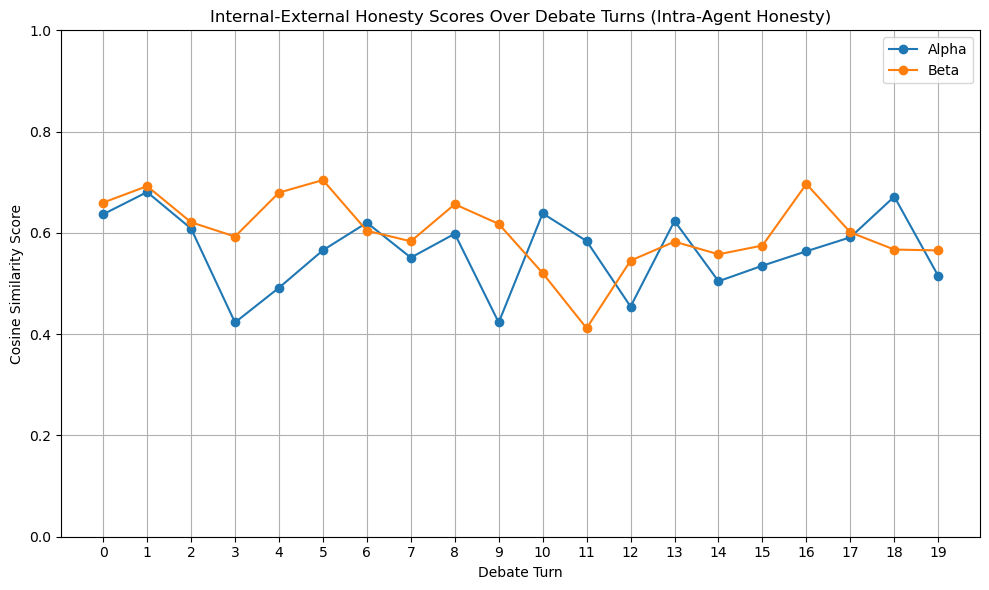

In [59]:
fig, ax = plt.subplots(figsize=(10, 6))
for speaker_name, data in intra_agent_scores.items():
    ax.plot(data["turns"], data["scores"], marker='o', label=speaker_name)
    
ax.set_title('Internal-External Honesty Scores Over Debate Turns (Intra-Agent Honesty)')
ax.set_xlabel('Debate Turn')
ax.set_ylabel('Cosine Similarity Score')
ax.set_ylim(0, 1)

max_turn = max((max(v["turns"]) for v in intra_agent_scores.values()), default=-1)
ax.set_xticks(range(0, max_turn + 1))
ax.legend()
ax.grid()
plt.tight_layout()

### Public vs Public Alignment and Private vs Private Alignment of Agents

In [60]:
inter_agent_alignment_external = analyzer.compute_inter_agent_alignment("public_speech", "public_speech")
inter_agent_alignment_internal = analyzer.compute_inter_agent_alignment("private_reflection", "private_reflection")

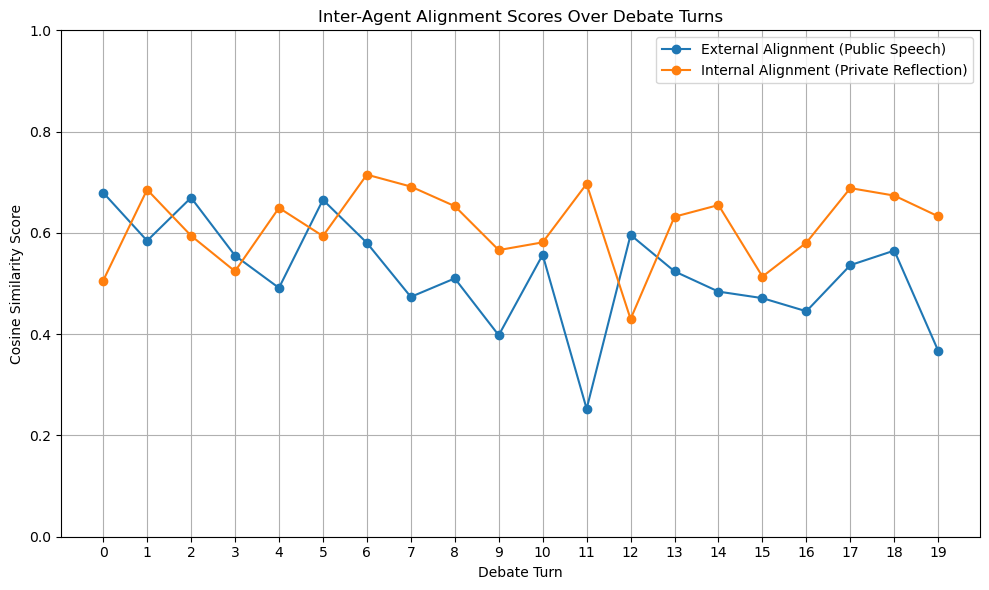

In [61]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(
    inter_agent_alignment_external["turns"],
    inter_agent_alignment_external["scores"],
    marker='o',
    label='External Alignment (Public Speech)',
)
ax.plot(
    inter_agent_alignment_internal["turns"],
    inter_agent_alignment_internal["scores"],
    marker='o',
    label='Internal Alignment (Private Reflection)',
)

ax.set_title('Inter-Agent Alignment Scores Over Debate Turns')
ax.set_xlabel('Debate Turn')
ax.set_ylabel('Cosine Similarity Score')
ax.set_ylim(0, 1)

max_turn = max(
    max(inter_agent_alignment_external["turns"], default=0),
    max(inter_agent_alignment_internal["turns"], default=0),
)
ax.set_xticks(range(0, max_turn + 1))
ax.legend()
ax.grid()
plt.tight_layout()